# 🔥 YOLOv8 Fire Detection – Improved Training Notebook

**Improvements over the original:**
- ✅ Upgraded model: `yolov8m.pt` (larger, more accurate)
- ✅ More epochs: 100 (was 20)
- ✅ Data Augmentation: copy_paste, mixup, stronger HSV, mosaic
- ✅ Cosine LR scheduler for smoother convergence
- ✅ Early stopping with patience=30
- ✅ Full training analysis & charts
- ✅ Model export to ONNX for deployment

**Dataset:** `continuous_fire` from Roboflow (1004 train / 754 val images, 1 class)

**Original Results (yolov8s, 20 epochs):**
- mAP@50 = 0.860 | mAP@50:95 = 0.609 | Precision = 0.783 | Recall = 0.789

## 1. Install Dependencies

In [2]:
!pip install ultralytics roboflow -q
print('✅ Dependencies installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 144.0 MB/s eta 0:00:00
✅ Dependencies installed


## 2. Imports & GPU Check

In [3]:
import ultralytics
import torch
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
from roboflow import Roboflow
from ultralytics import YOLO
from IPython.display import Image, display

print(f'Ultralytics version : {ultralytics.__version__}')
print(f'PyTorch version     : {torch.__version__}')
print(f'CUDA available      : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU                 : {torch.cuda.get_device_name(0)}')
    print(f'VRAM                : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version : 8.4.75
PyTorch version     : 2.11.0+cu128
CUDA available      : True
GPU                 : Tesla T4
VRAM                : 15.6 GB


## 3. Download Dataset from Roboflow

In [4]:
rf = Roboflow(api_key="0H16OpSbc2GAowYzKWU4")
project = rf.workspace("mohamed-esam-vepc0").project("continuous_fire-gdoc7")
version = project.version(1)
dataset = version.download("yolov8")

DATA_YAML = None
for root, dirs, files in os.walk('/content'):
    if 'data.yaml' in files:
        DATA_YAML = os.path.join(root, 'data.yaml')
        break

print(f'✅ Dataset ready  →  {DATA_YAML}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to continuous_fire-1 in yolov8:: 100%|██████████| 5023/5023 [00:00<00:00, 12862.13it/s]


✅ Dataset ready  →  /content/continuous_fire-1/data.yaml


## 4. Dataset Exploration & Statistics

In [5]:
import yaml

with open(DATA_YAML) as f:
    data_config = yaml.safe_load(f)

print('📊 Dataset Configuration:')
print(f'  Classes : {data_config.get("nc", "N/A")} → {data_config.get("names", [])}')

dataset_dir = os.path.dirname(DATA_YAML)
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(dataset_dir, split, 'images')
    if os.path.exists(img_dir):
        n = len(glob.glob(os.path.join(img_dir, '*.jpg')))
        n += len(glob.glob(os.path.join(img_dir, '*.png')))
        print(f'  {split:8s}: {n} images')

lbl_dir = os.path.join(dataset_dir, 'train', 'labels')
total_boxes = 0
if os.path.exists(lbl_dir):
    for lbl_file in glob.glob(os.path.join(lbl_dir, '*.txt')):
        with open(lbl_file) as f:
            lines = [l.strip() for l in f if l.strip()]
            total_boxes += len(lines)
print(f'  Train bounding boxes: {total_boxes}')
print(f'  Avg boxes/image     : {total_boxes / max(1, len(glob.glob(os.path.join(dataset_dir, "train", "images", "*.jpg")))):.1f}')

📊 Dataset Configuration:
  Classes : 1 → ['fire']
  train   : 1004 images
  valid   : 754 images
  test    : 751 images
  Train bounding boxes: 1538
  Avg boxes/image     : 1.5


## 5. Original Training Results (20 Epochs – Reference)

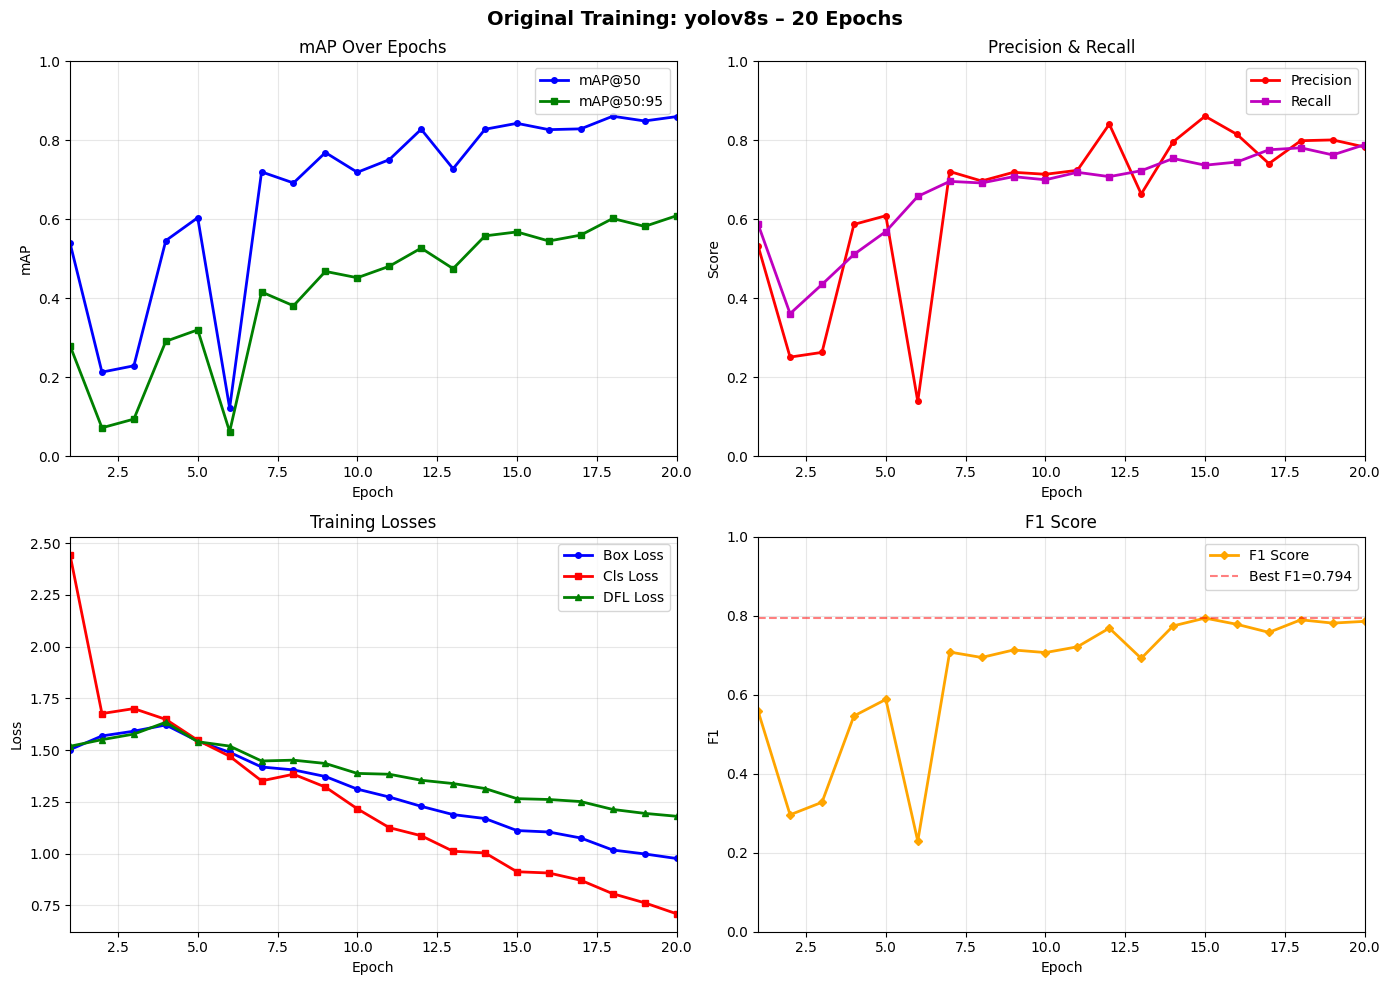


📊 ORIGINAL FINAL METRICS (Epoch 20):
   mAP@50     = 0.860
   mAP@50:95  = 0.609
   Precision  = 0.783
   Recall     = 0.789
   F1 Score   = 0.786
   Best mAP@50 = 0.861 (Epoch 18)


In [6]:
orig_epochs    = list(range(1, 21))
orig_map50     = [0.540, 0.213, 0.229, 0.546, 0.604, 0.122, 0.720, 0.692, 0.769, 0.719,
                  0.751, 0.828, 0.728, 0.828, 0.843, 0.827, 0.829, 0.861, 0.849, 0.860]
orig_map5095   = [0.280, 0.072, 0.094, 0.291, 0.320, 0.062, 0.416, 0.381, 0.468, 0.452,
                  0.481, 0.527, 0.475, 0.558, 0.568, 0.545, 0.560, 0.602, 0.582, 0.609]
orig_precision = [0.532, 0.251, 0.263, 0.587, 0.609, 0.139, 0.721, 0.697, 0.719, 0.714,
                  0.724, 0.841, 0.664, 0.796, 0.861, 0.815, 0.741, 0.799, 0.801, 0.783]
orig_recall    = [0.587, 0.361, 0.435, 0.511, 0.569, 0.658, 0.696, 0.692, 0.708, 0.700,
                  0.719, 0.708, 0.723, 0.754, 0.737, 0.745, 0.776, 0.781, 0.763, 0.789]
orig_box_loss  = [1.503, 1.569, 1.592, 1.622, 1.544, 1.490, 1.419, 1.405, 1.373, 1.312,
                  1.274, 1.229, 1.189, 1.170, 1.112, 1.105, 1.076, 1.018, 0.999, 0.977]
orig_cls_loss  = [2.444, 1.677, 1.701, 1.649, 1.548, 1.471, 1.352, 1.384, 1.322, 1.217,
                  1.126, 1.087, 1.012, 1.004, 0.913, 0.907, 0.872, 0.807, 0.763, 0.710]
orig_dfl_loss  = [1.519, 1.551, 1.578, 1.635, 1.541, 1.520, 1.448, 1.452, 1.436, 1.388,
                  1.384, 1.355, 1.339, 1.315, 1.266, 1.262, 1.252, 1.214, 1.195, 1.181]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Original Training: yolov8s – 20 Epochs', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.plot(orig_epochs, orig_map50,   'b-o', ms=4, lw=2, label='mAP@50')
ax.plot(orig_epochs, orig_map5095, 'g-s', ms=4, lw=2, label='mAP@50:95')
ax.set(title='mAP Over Epochs', xlabel='Epoch', ylabel='mAP', xlim=(1,20), ylim=(0,1))
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(orig_epochs, orig_precision, 'r-o', ms=4, lw=2, label='Precision')
ax.plot(orig_epochs, orig_recall,    'm-s', ms=4, lw=2, label='Recall')
ax.set(title='Precision & Recall', xlabel='Epoch', ylabel='Score', xlim=(1,20), ylim=(0,1))
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(orig_epochs, orig_box_loss, 'b-o', ms=4, lw=2, label='Box Loss')
ax.plot(orig_epochs, orig_cls_loss, 'r-s', ms=4, lw=2, label='Cls Loss')
ax.plot(orig_epochs, orig_dfl_loss, 'g-^', ms=4, lw=2, label='DFL Loss')
ax.set(title='Training Losses', xlabel='Epoch', ylabel='Loss', xlim=(1,20))
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 1]
f1 = [2*p*r/(p+r) if (p+r)>0 else 0 for p,r in zip(orig_precision, orig_recall)]
ax.plot(orig_epochs, f1, color='orange', marker='D', ms=4, lw=2, label='F1 Score')
ax.axhline(y=max(f1), ls='--', color='red', alpha=0.5, label=f'Best F1={max(f1):.3f}')
ax.set(title='F1 Score', xlabel='Epoch', ylabel='F1', xlim=(1,20), ylim=(0,1))
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n📊 ORIGINAL FINAL METRICS (Epoch 20):')
print(f'   mAP@50     = {orig_map50[-1]:.3f}')
print(f'   mAP@50:95  = {orig_map5095[-1]:.3f}')
print(f'   Precision  = {orig_precision[-1]:.3f}')
print(f'   Recall     = {orig_recall[-1]:.3f}')
print(f'   F1 Score   = {f1[-1]:.3f}')
print(f'   Best mAP@50 = {max(orig_map50):.3f} (Epoch {orig_map50.index(max(orig_map50))+1})')

## 6. Instability Diagnosis

In [7]:
print('🔍 TRAINING INSTABILITY ANALYSIS:')
print('─' * 50)
for i in range(1, len(orig_map50)):
    delta = orig_map50[i] - orig_map50[i-1]
    flag = ' ⚠️ BIG DROP' if delta < -0.1 else (' 📈 +big' if delta > 0.1 else '')
    print(f'  Epoch {i+1:2d}: mAP50={orig_map50[i]:.3f}  Δ={delta:+.3f}{flag}')

print('\n💡 ROOT CAUSE: Default LR schedule can cause oscillations.')
print('   FIX: cos_lr=True, lower lr0, more epochs, data augmentation.')

🔍 TRAINING INSTABILITY ANALYSIS:
──────────────────────────────────────────────────
  Epoch  2: mAP50=0.213  Δ=-0.327 ⚠️ BIG DROP
  Epoch  3: mAP50=0.229  Δ=+0.016
  Epoch  4: mAP50=0.546  Δ=+0.317 📈 +big
  Epoch  5: mAP50=0.604  Δ=+0.058
  Epoch  6: mAP50=0.122  Δ=-0.482 ⚠️ BIG DROP
  Epoch  7: mAP50=0.720  Δ=+0.598 📈 +big
  Epoch  8: mAP50=0.692  Δ=-0.028
  Epoch  9: mAP50=0.769  Δ=+0.077
  Epoch 10: mAP50=0.719  Δ=-0.050
  Epoch 11: mAP50=0.751  Δ=+0.032
  Epoch 12: mAP50=0.828  Δ=+0.077
  Epoch 13: mAP50=0.728  Δ=-0.100
  Epoch 14: mAP50=0.828  Δ=+0.100
  Epoch 15: mAP50=0.843  Δ=+0.015
  Epoch 16: mAP50=0.827  Δ=-0.016
  Epoch 17: mAP50=0.829  Δ=+0.002
  Epoch 18: mAP50=0.861  Δ=+0.032
  Epoch 19: mAP50=0.849  Δ=-0.012
  Epoch 20: mAP50=0.860  Δ=+0.011

💡 ROOT CAUSE: Default LR schedule can cause oscillations.
   FIX: cos_lr=True, lower lr0, more epochs, data augmentation.


## 7. Model Size vs Accuracy Comparison

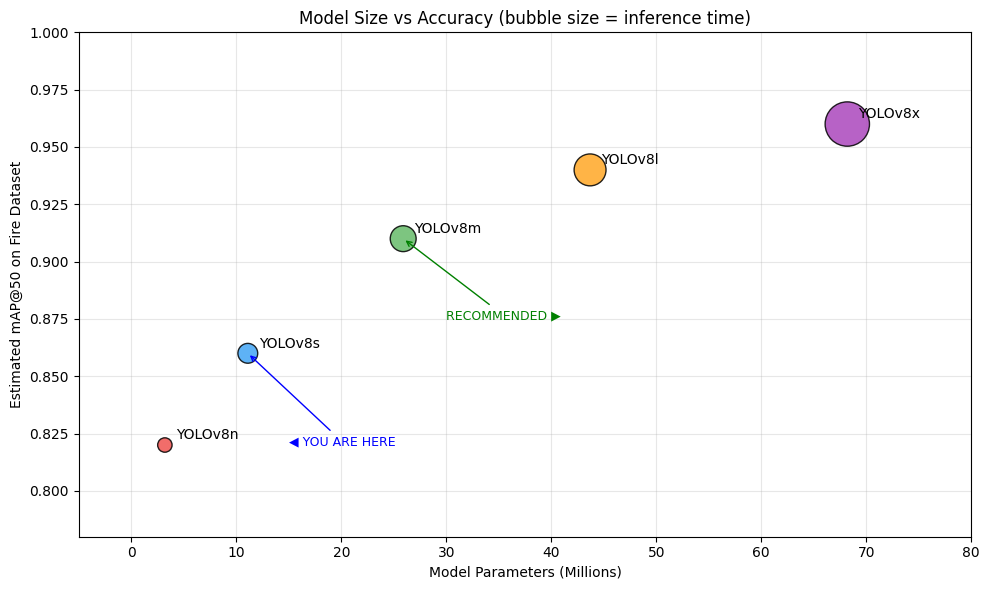

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
models    = ['YOLOv8n', 'YOLOv8s', 'YOLOv8m', 'YOLOv8l', 'YOLOv8x']
params_m  = [3.2, 11.1, 25.9, 43.7, 68.2]
speed_ms  = [0.9, 1.7,  2.9,  4.4,  8.5]
map_est   = [0.82, 0.86, 0.91, 0.94, 0.96]
colors    = ['#EF5350', '#42A5F5', '#66BB6A', '#FFA726', '#AB47BC']

ax.scatter(params_m, map_est, s=[s*120 for s in speed_ms],
           c=colors, alpha=0.85, edgecolors='black', linewidth=1, zorder=3)
for m, p, e in zip(models, params_m, map_est):
    ax.annotate(m, (p, e), textcoords='offset points', xytext=(8,4), fontsize=10)

ax.annotate('◀ YOU ARE HERE', xy=(11.1, 0.86), xytext=(15, 0.82),
            arrowprops=dict(arrowstyle='->', color='blue'), color='blue', fontsize=9)
ax.annotate('RECOMMENDED ▶', xy=(25.9, 0.91), xytext=(30, 0.875),
            arrowprops=dict(arrowstyle='->', color='green'), color='green', fontsize=9)

ax.set(xlabel='Model Parameters (Millions)', ylabel='Estimated mAP@50 on Fire Dataset',
       title='Model Size vs Accuracy (bubble size = inference time)',
       xlim=(-5, 80), ylim=(0.78, 1.0))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Data Augmentation Strategy

In [9]:
aug_info = {
    'Technique':    ['Mosaic', 'Flip LR', 'HSV Hue', 'HSV Saturation', 'HSV Value',
                     'Random Erasing', 'Blur', 'Scale', 'Copy-Paste', 'Degrees'],
    'Original':     [1.0, 0.5, 0.015, 0.7,  0.4, 0.4, 0.01, 0.5, 0.0, 0.0],
    'Improved':     [1.0, 0.5, 0.02,  0.75, 0.45, 0.4, 0.02, 0.6, 0.3, 5.0],
}
df_aug = pd.DataFrame(aug_info)
print('📊 AUGMENTATION COMPARISON:')
print(df_aug.to_string(index=False))

📊 AUGMENTATION COMPARISON:
     Technique  Original  Improved
        Mosaic     1.000      1.00
       Flip LR     0.500      0.50
       HSV Hue     0.015      0.02
HSV Saturation     0.700      0.75
     HSV Value     0.400      0.45
Random Erasing     0.400      0.40
          Blur     0.010      0.02
         Scale     0.500      0.60
    Copy-Paste     0.000      0.30
       Degrees     0.000      5.00


## 9. 🚀 Improved Training

Key improvements: `yolov8m.pt`, 100 epochs, `cos_lr=True`, `copy_paste=0.3`, early stopping.

In [ ]:
model = YOLO('yolov8s.pt')  

results = model.train(
    data      = DATA_YAML,
    imgsz     = 640,
    batch     = 32,         
    epochs    = 100,
    patience  = 20,
    cos_lr    = True,
    lr0       = 0.01,
    optimizer = 'SGD',      
    mosaic    = 1.0,
    copy_paste= 0.1,        
    degrees   = 3.0,
    fliplr    = 0.5,
    hsv_h     = 0.015,
    hsv_s     = 0.7,
    hsv_v     = 0.4,
    plots     = True,
    save      = True,
    project   = '/content/runs/detect',
    name      = 'fire_v3',
)

print('\n✅ Training complete!')
print(f'   Best model saved to: {results.save_dir}/weights/best.pt')

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/continuous_fire-1/data.yaml, degrees=3.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fire_v3, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patie

## 10. Post-Training Analysis & Charts

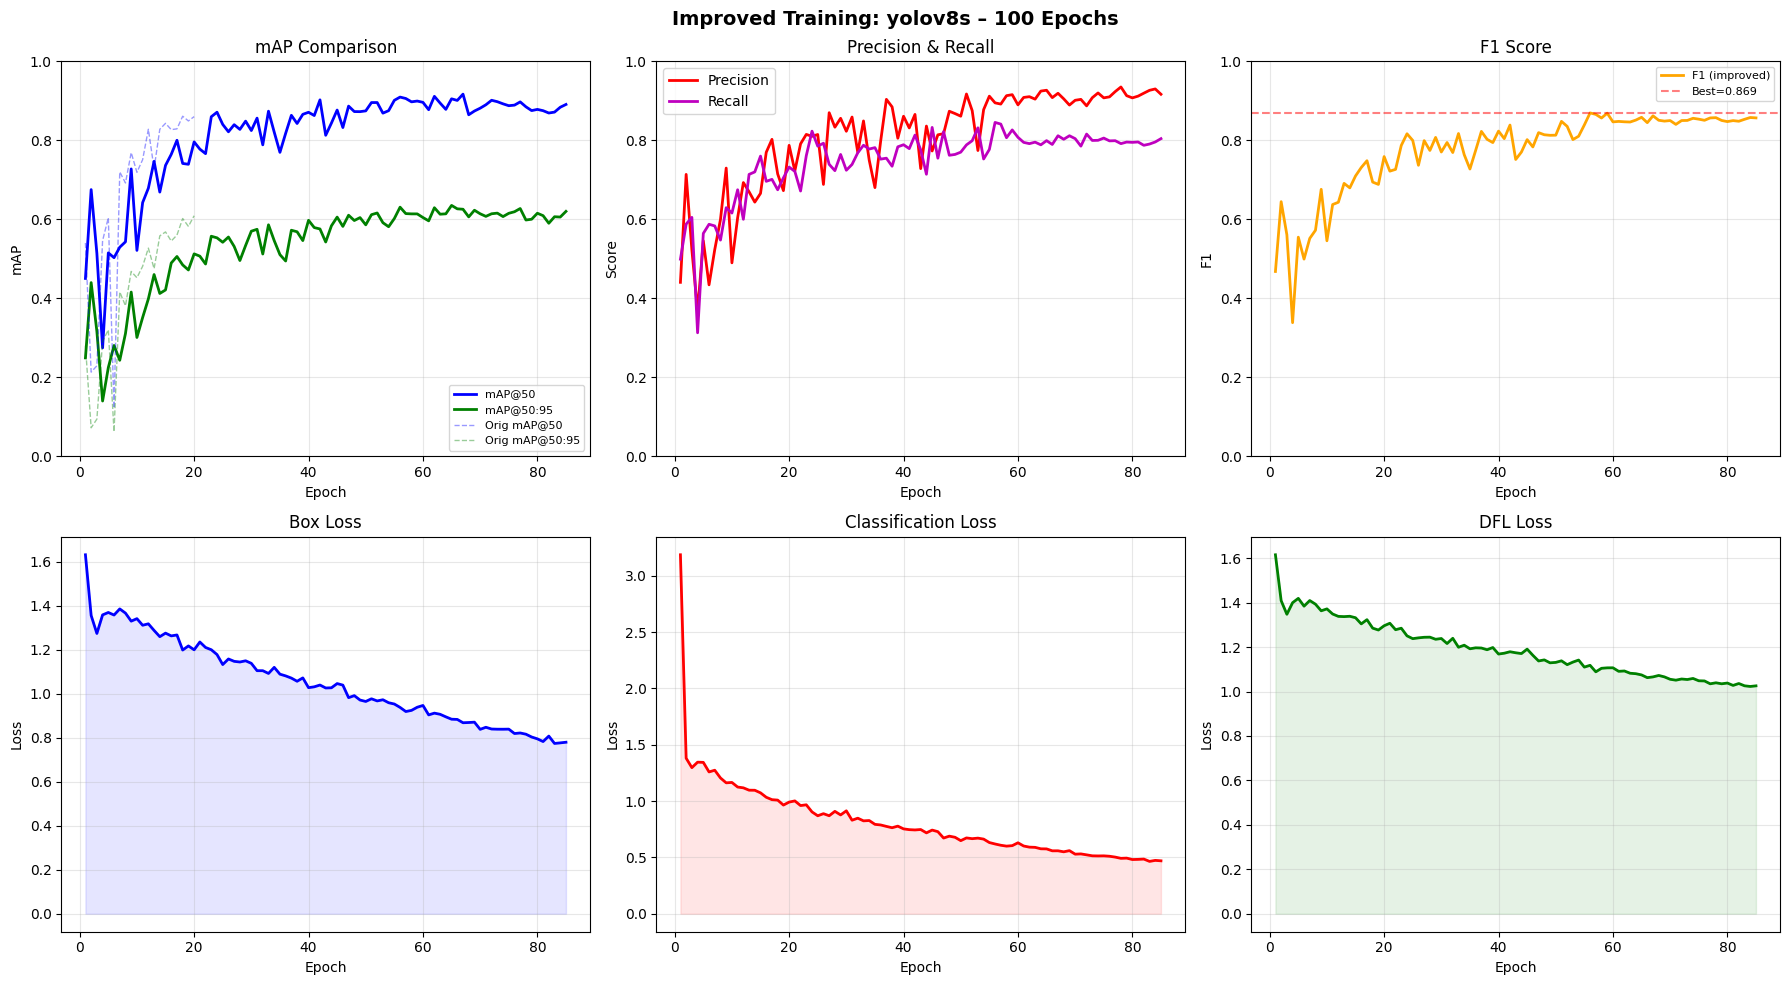

In [15]:
csv_path = f'{results.save_dir}/results.csv'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()
ep = df['epoch'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Improved Training: yolov8s – 100 Epochs', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.plot(ep, df['metrics/mAP50(B)'],    'b-', lw=2, label='mAP@50')
ax.plot(ep, df['metrics/mAP50-95(B)'], 'g-', lw=2, label='mAP@50:95')
ax.plot(orig_epochs, orig_map50,   'b--', lw=1, alpha=0.4, label='Orig mAP@50')
ax.plot(orig_epochs, orig_map5095, 'g--', lw=1, alpha=0.4, label='Orig mAP@50:95')
ax.set(title='mAP Comparison', xlabel='Epoch', ylabel='mAP', ylim=(0,1))
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(ep, df['metrics/precision(B)'], 'r-', lw=2, label='Precision')
ax.plot(ep, df['metrics/recall(B)'],    'm-', lw=2, label='Recall')
ax.set(title='Precision & Recall', xlabel='Epoch', ylabel='Score', ylim=(0,1))
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 2]
prec = df['metrics/precision(B)']
rec  = df['metrics/recall(B)']
f1_new = 2 * prec * rec / (prec + rec + 1e-8)
ax.plot(ep, f1_new, color='orange', lw=2, label='F1 (improved)')
ax.axhline(y=f1_new.max(), ls='--', color='red', alpha=0.5, label=f'Best={f1_new.max():.3f}')
ax.set(title='F1 Score', xlabel='Epoch', ylabel='F1', ylim=(0,1))
ax.legend(fontsize=8); ax.grid(alpha=0.3)

for ax, col, label, color in zip(
        [axes[1,0], axes[1,1], axes[1,2]],
        ['train/box_loss', 'train/cls_loss', 'train/dfl_loss'],
        ['Box Loss', 'Classification Loss', 'DFL Loss'],
        ['blue', 'red', 'green']):
    if col in df.columns:
        ax.plot(ep, df[col], color=color, lw=2)
        ax.fill_between(ep, df[col], alpha=0.1, color=color)
    ax.set(title=label, xlabel='Epoch', ylabel='Loss')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Validation Results

In [16]:
best_pt = f'{results.save_dir}/weights/best.pt'
val_model = YOLO(best_pt)
val_results = val_model.val(data=DATA_YAML, imgsz=640, verbose=True)

print('\n' + '='*55)
print('  VALIDATION RESULTS (best.pt)')
print('='*55)
print(f'  mAP@50      = {val_results.box.map50:.4f}')
print(f'  mAP@50:95   = {val_results.box.map:.4f}')
print(f'  Precision   = {val_results.box.p[0]:.4f}')
print(f'  Recall      = {val_results.box.r[0]:.4f}')
f1_val = 2 * val_results.box.p[0] * val_results.box.r[0] / (val_results.box.p[0] + val_results.box.r[0] + 1e-8)
print(f'  F1 Score    = {f1_val:.4f}')
print('='*55)
print('\n📊 IMPROVEMENT vs ORIGINAL:')
print(f'  mAP@50     : 0.860 → {val_results.box.map50:.3f}  (Δ={val_results.box.map50-0.860:+.3f})')
print(f'  mAP@50:95  : 0.609 → {val_results.box.map:.3f}  (Δ={val_results.box.map-0.609:+.3f})')
print(f'  Precision  : 0.783 → {val_results.box.p[0]:.3f}  (Δ={val_results.box.p[0]-0.783:+.3f})')
print(f'  Recall     : 0.789 → {val_results.box.r[0]:.3f}  (Δ={val_results.box.r[0]-0.789:+.3f})')

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 538.3±213.1 MB/s, size: 8.7 KB)
val: Scanning /content/continuous_fire-1/valid/labels.cache... 754 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 754/754 166.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 48/48 3.2it/s 15.1s
                   all        754        950      0.926      0.798      0.902      0.634
Speed: 2.4ms preprocess, 10.7ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val-2

  VALIDATION RESULTS (best.pt)
  mAP@50      = 0.9016
  mAP@50:95   = 0.6343
  Precision   = 0.9255
  Recall      = 0.7981
  F1 Score    = 0.8571

📊 IMPROVEMENT vs ORIGINAL:
  mAP@50     : 0.860 → 0.902  (Δ=+0.042)
  mAP@50:95  : 0.609 → 0.634  (Δ=+0.025)
  Precisi

## 12. Built-in Ultralytics Plots


🖼️  Training Curves


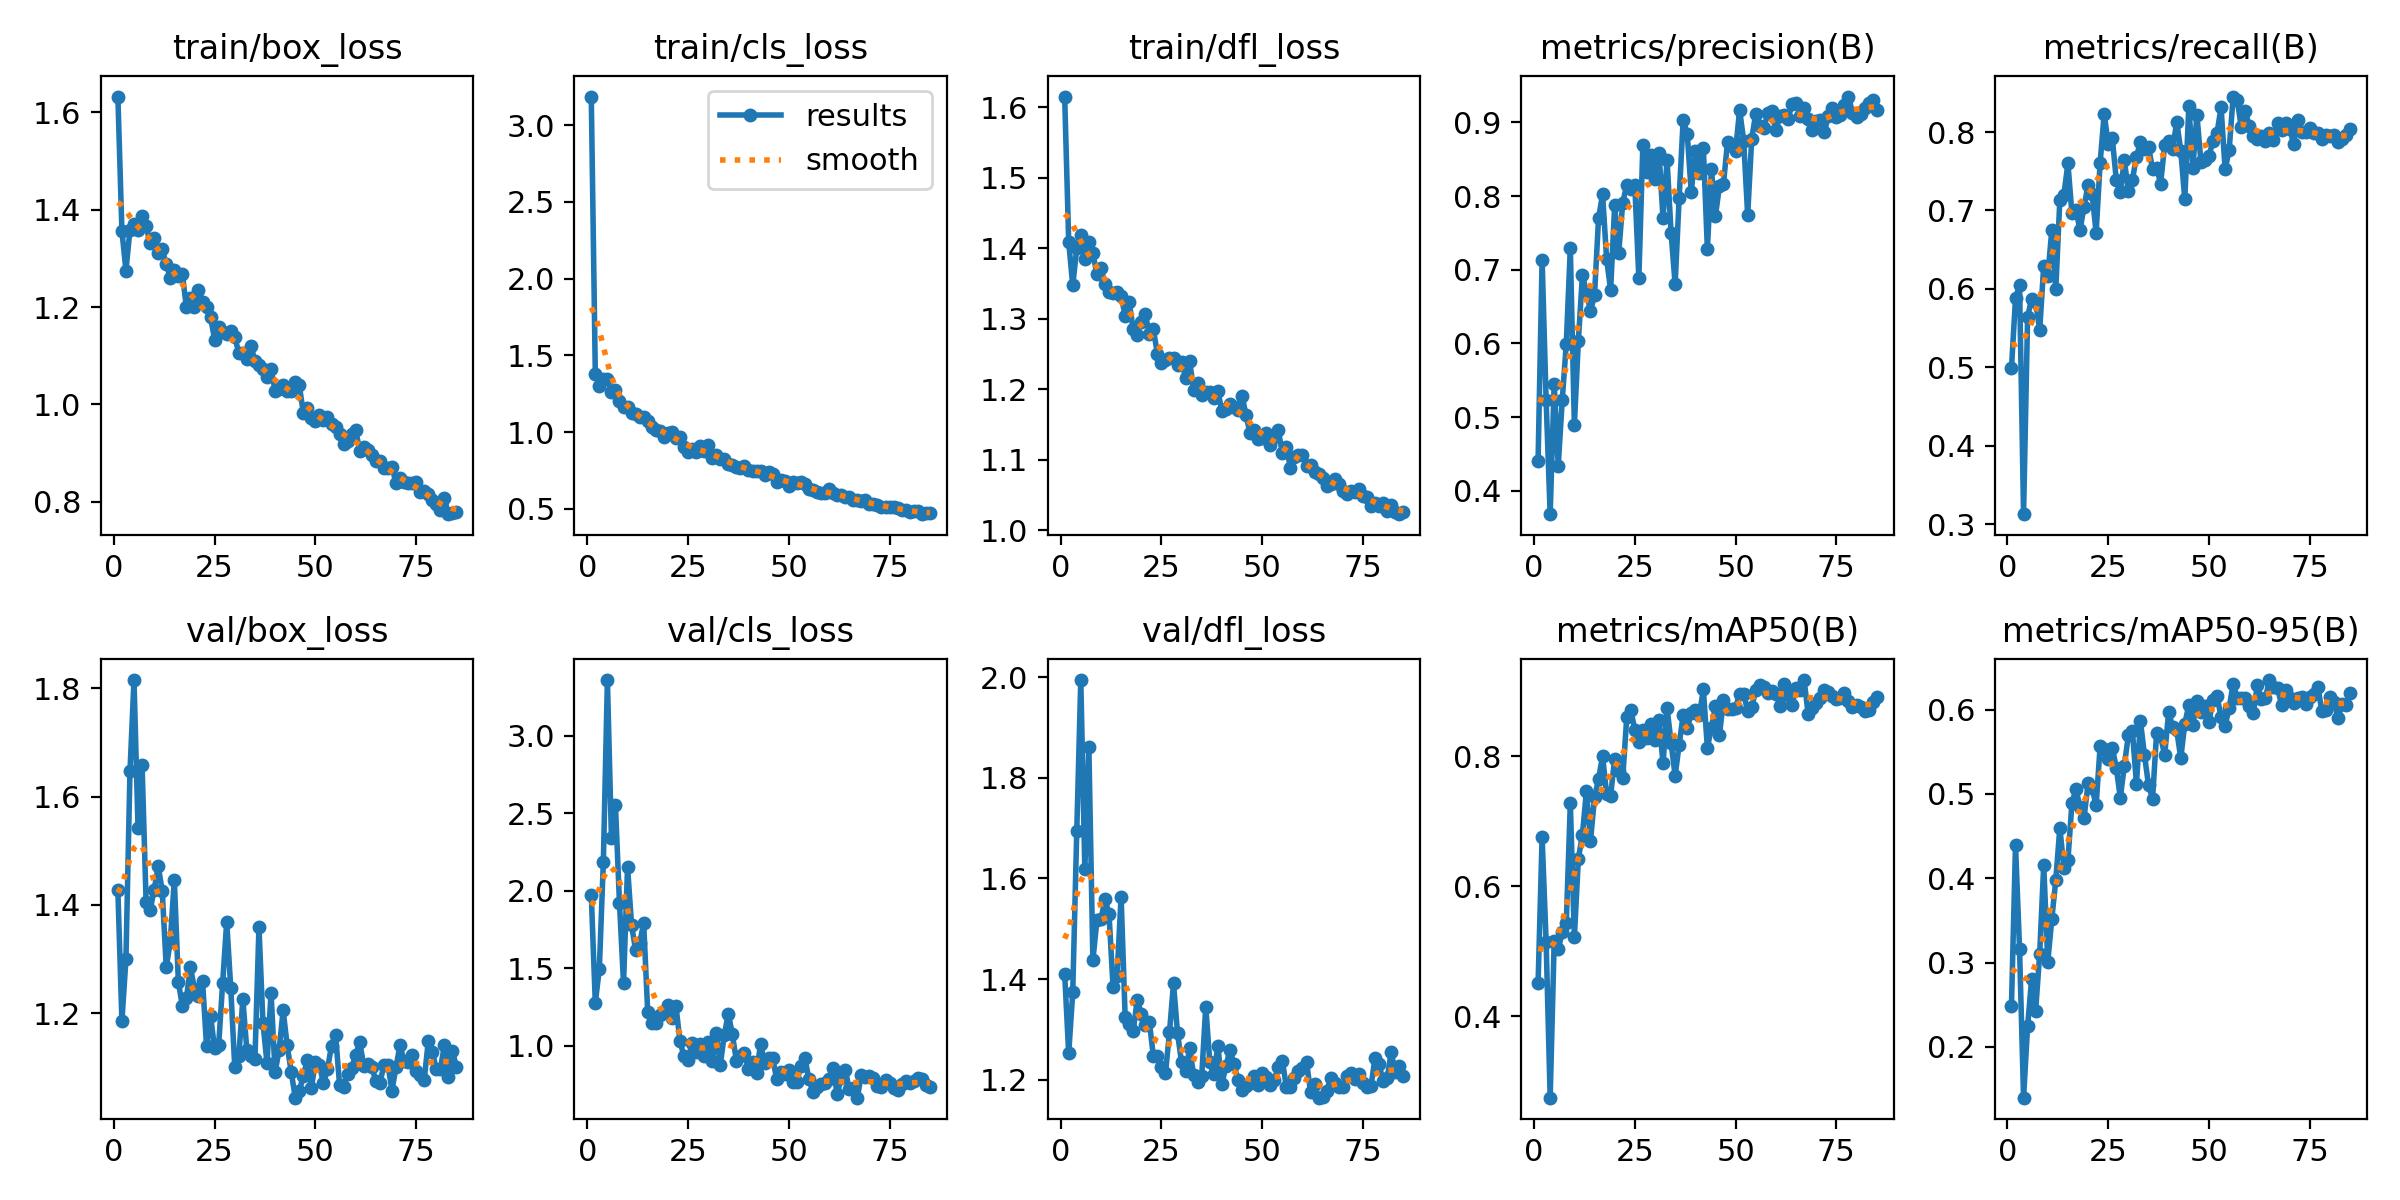


🖼️  Confusion Matrix


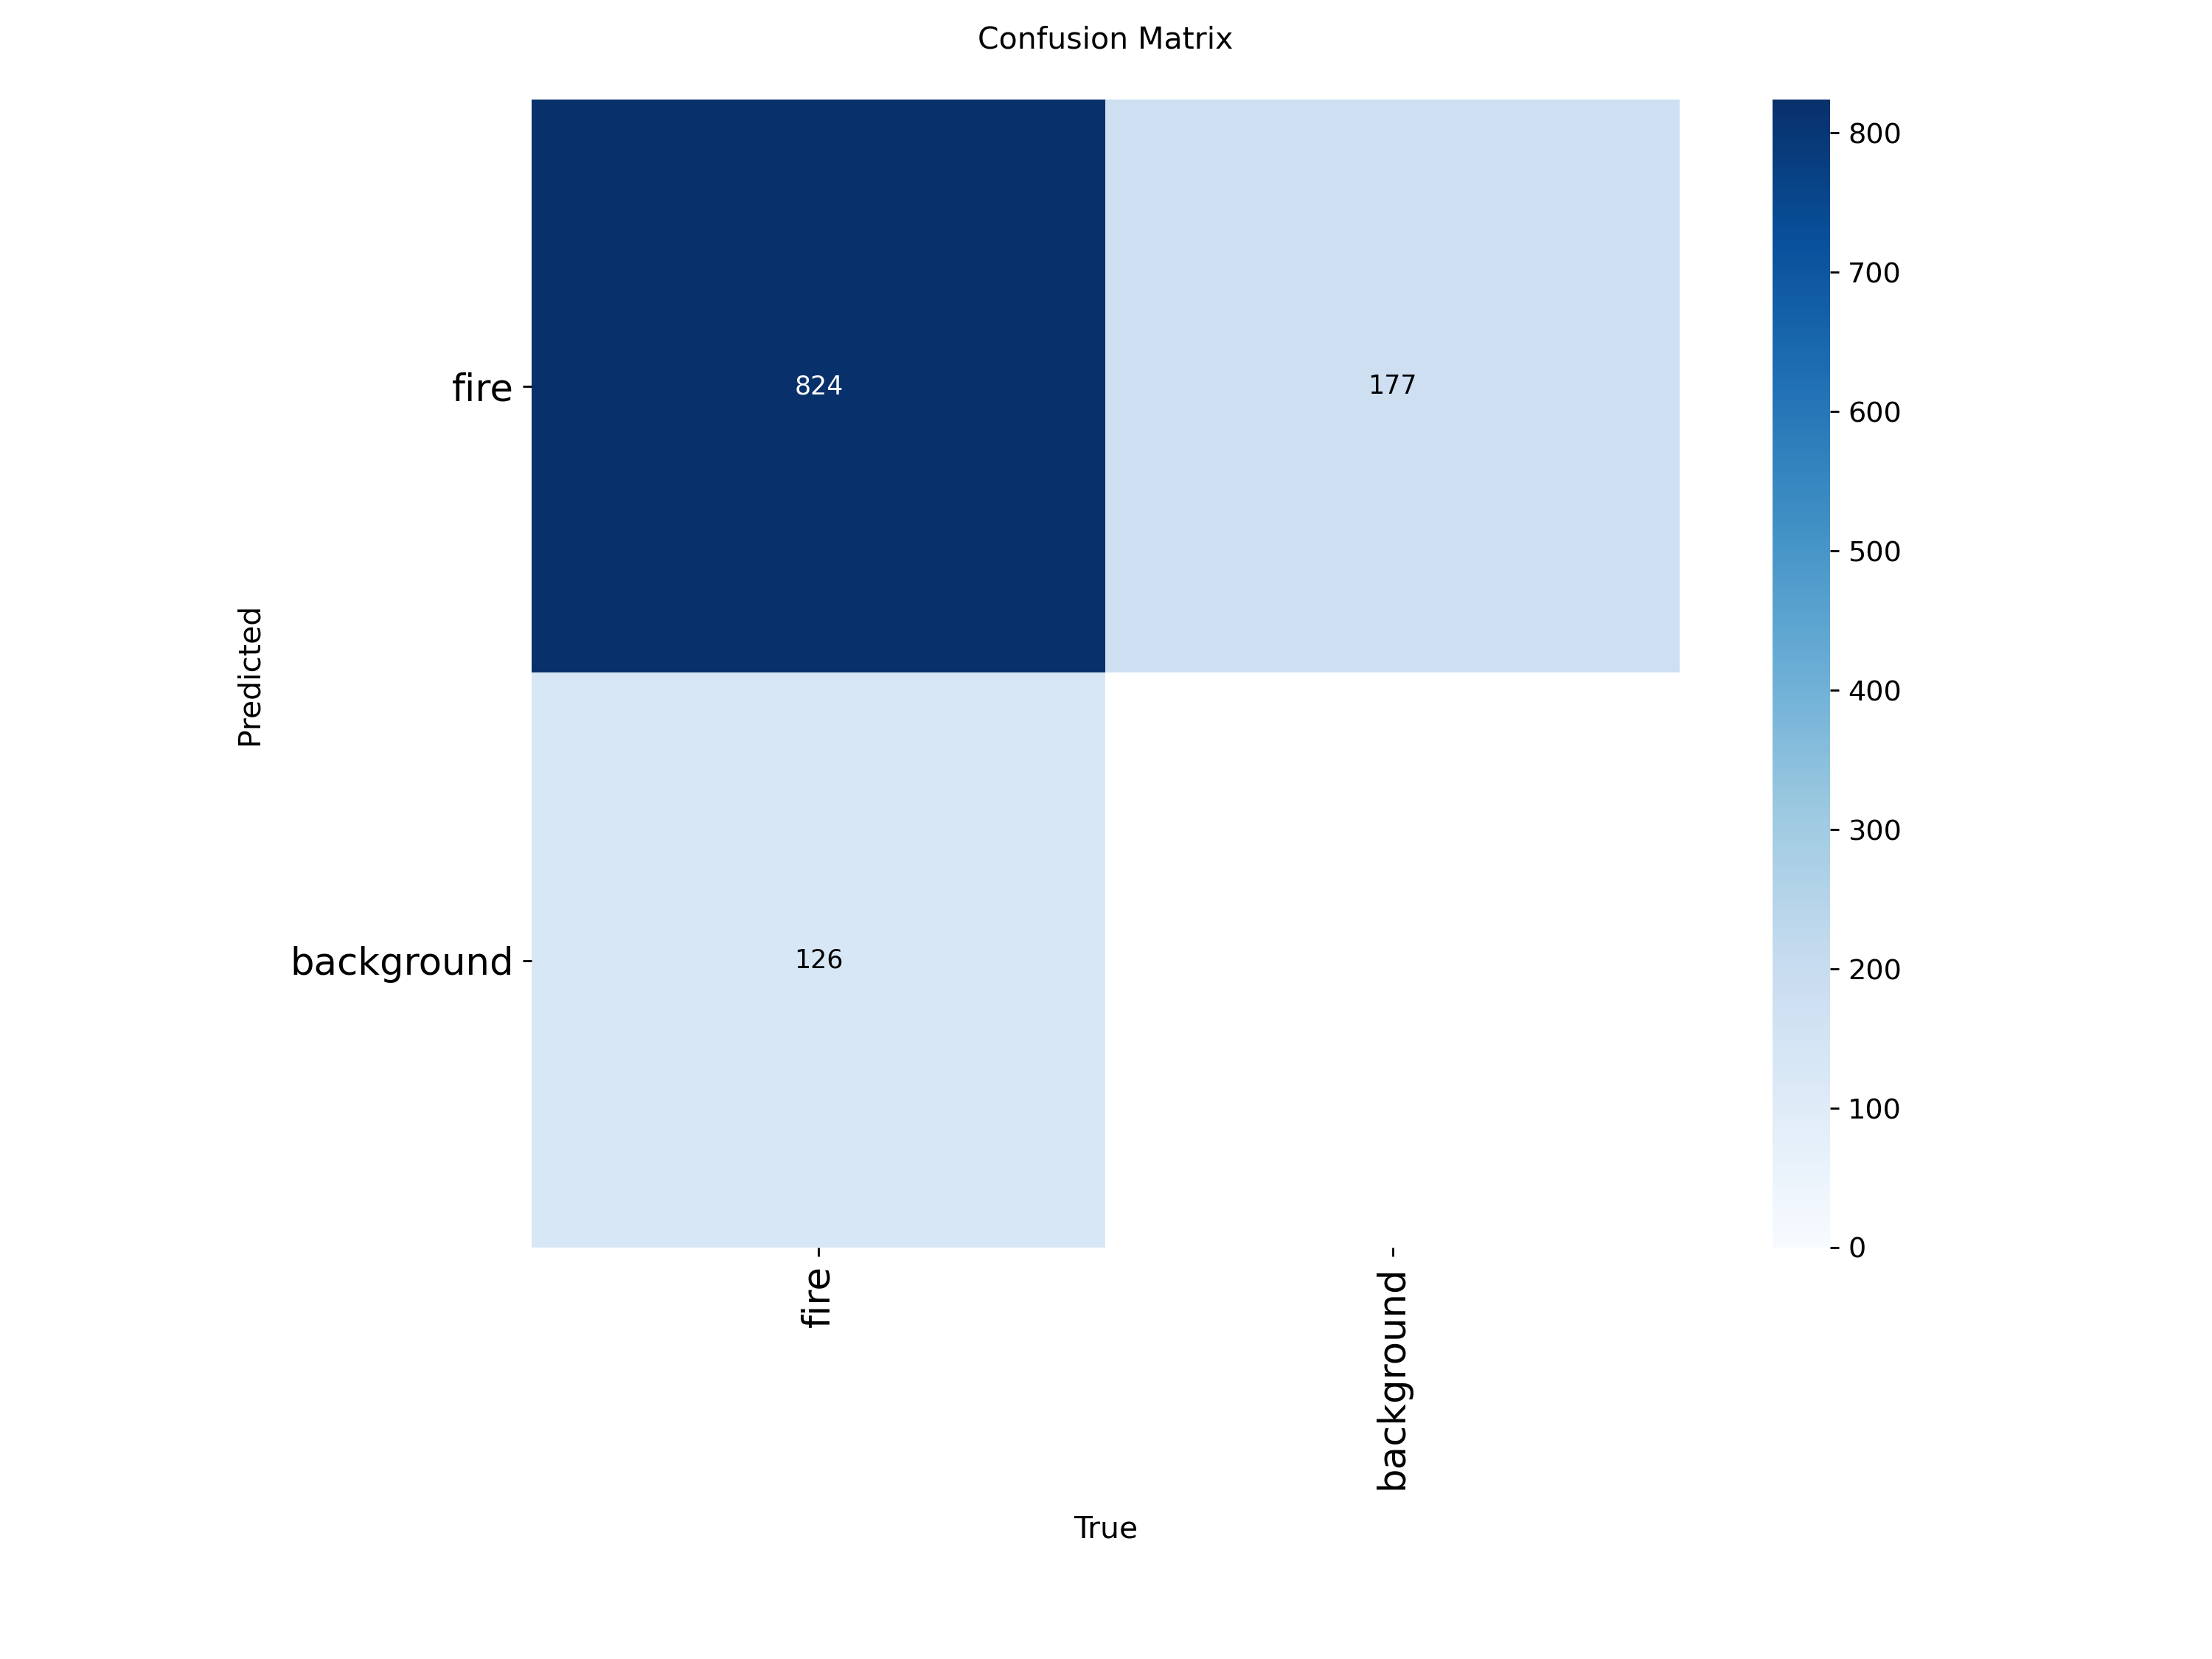

⚠️  PR_curve.png not found
⚠️  F1_curve.png not found

🖼️  Label Distribution


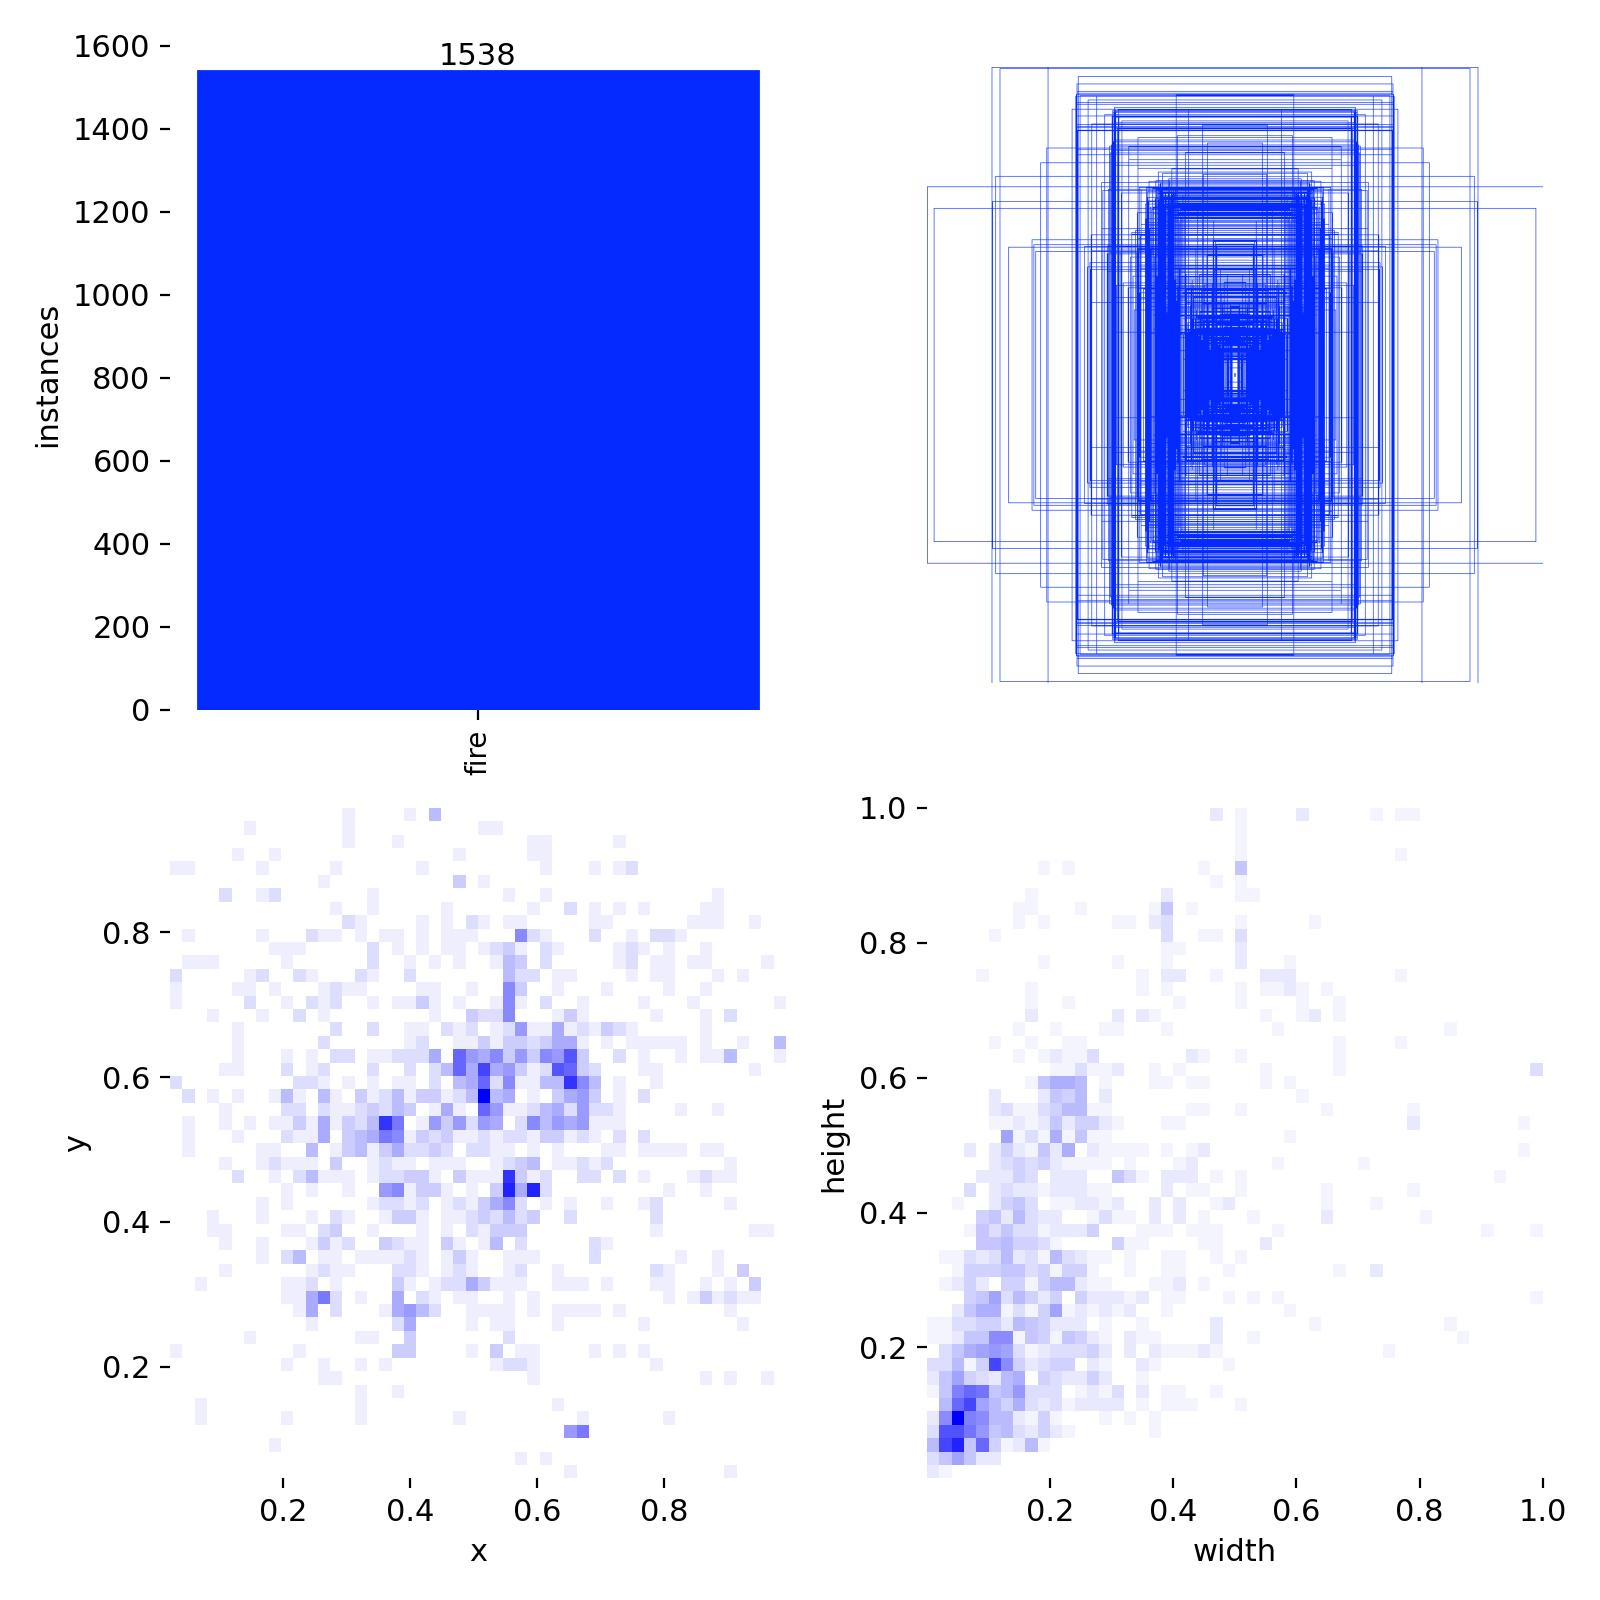

In [17]:
save_dir = results.save_dir
plot_files = [
    ('results.png',          'Training Curves'),
    ('confusion_matrix.png', 'Confusion Matrix'),
    ('PR_curve.png',         'Precision-Recall Curve'),
    ('F1_curve.png',         'F1 Curve'),
    ('labels.jpg',           'Label Distribution'),
]
for fname, title in plot_files:
    fpath = os.path.join(save_dir, fname)
    if os.path.exists(fpath):
        print(f'\n🖼️  {title}')
        display(Image(filename=fpath, width=700))
    else:
        print(f'⚠️  {fname} not found')

## 13. Sample Predictions on Validation Images


image 1/6 /content/continuous_fire-1/valid/images/Img_25843_jpg.rf.9c366c9a4ca36e81e2aa6c80f2eee6fb.jpg: 640x640 1 fire, 16.7ms
image 2/6 /content/continuous_fire-1/valid/images/Img_25969_jpg.rf.19dbb70dcb866d432a7f4cbab319cf9d.jpg: 640x640 1 fire, 16.4ms
image 3/6 /content/continuous_fire-1/valid/images/FireDataThree18043_png.rf.93ff99c07ec8aeb4938fff7b85ef07ae.jpg: 640x640 1 fire, 16.3ms
image 4/6 /content/continuous_fire-1/valid/images/FireDataThree12925_png.rf.37542bc74848fd5d5e1e9332634e187f.jpg: 640x640 1 fire, 16.2ms
image 5/6 /content/continuous_fire-1/valid/images/HouseFive25_png.rf.fd3df0b0181ce31cc57c30394be4f614.jpg: 640x640 1 fire, 17.5ms
image 6/6 /content/continuous_fire-1/valid/images/Img_7897_jpg.rf.9b161f75d116c9242fb31c12af21c3c5.jpg: 640x640 1 fire, 16.2ms
Speed: 4.1ms preprocess, 16.5ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/val_preds


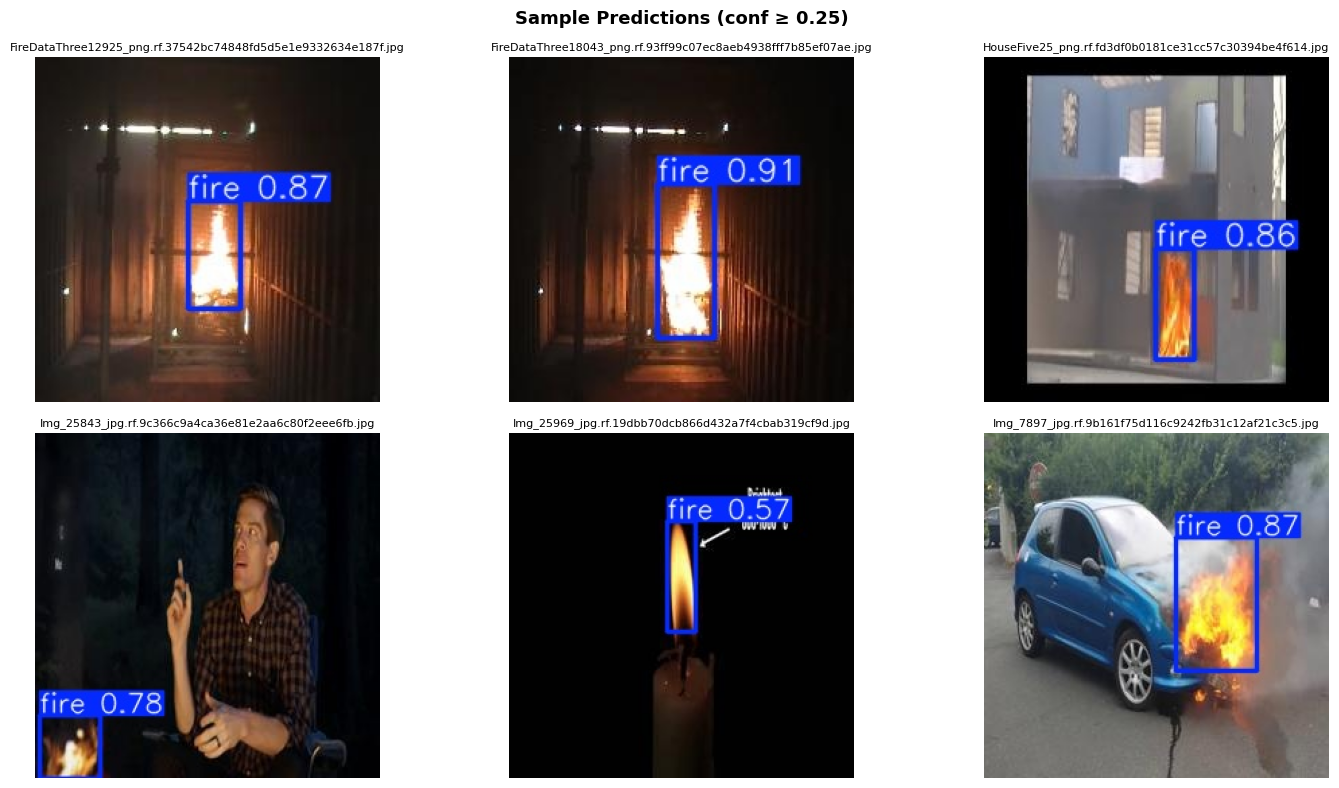

In [18]:
import random
from PIL import Image as PILImage

dataset_dir = os.path.dirname(DATA_YAML)
val_images  = glob.glob(os.path.join(dataset_dir, 'valid', 'images', '*.jpg'))
val_images += glob.glob(os.path.join(dataset_dir, 'valid', 'images', '*.png'))
sample_imgs = random.sample(val_images, min(6, len(val_images)))

best_model = YOLO(best_pt)
preds = best_model.predict(source=sample_imgs, conf=0.25, save=True,
                            project='/content/runs/detect', name='val_preds')

pred_dir   = '/content/runs/detect/val_preds'
pred_files = sorted(glob.glob(os.path.join(pred_dir, '*.jpg')))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Sample Predictions (conf ≥ 0.25)', fontsize=13, fontweight='bold')
for ax, pf in zip(axes.flatten(), pred_files[:6]):
    img = mpimg.imread(pf)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(os.path.basename(pf), fontsize=8)
plt.tight_layout()
plt.show()

## 14. Export to ONNX

In [19]:
best_model = YOLO(best_pt)
onnx_path = best_model.export(format='onnx', imgsz=640, simplify=True)
print(f'✅ ONNX exported  →  {onnx_path}')
for path, name in [(best_pt, 'PyTorch (.pt)'), (onnx_path, 'ONNX (.onnx)')]:
    size_mb = os.path.getsize(path) / 1e6
    print(f'   {name:20s}: {size_mb:.1f} MB')

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from '/content/runs/detect/fire_v3/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 297ms
Prepared 4 packages in 1.87s
Installed 4 packages in 269ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming 

## 15. Download Best Model

In [20]:
from google.colab import files
print('Downloading best.pt ...')
files.download(best_pt)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 16. Production Inference Code

After downloading `best.pt`, use the code below locally:
```
pip install ultralytics
```

In [ ]:
production_code = '''
from ultralytics import YOLO
import cv2

model = YOLO('best.pt')

# Image inference
results = model.predict('fire_image.jpg', conf=0.25, save=True)
for r in results:
    print(f'Detected {len(r.boxes)} fire regions')
    for box in r.boxes:
        print(f'  conf={box.conf[0]:.2f}  bbox={box.xyxy[0].tolist()}')

# Webcam / Video inference
cap = cv2.VideoCapture(0)
while True:
    ret, frame = cap.read()
    if not ret:
        break
    results = model.predict(frame, conf=0.25)
    annotated = results[0].plot()
    cv2.imshow('Fire Detection', annotated)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()
'''
print(production_code)

---
## Summary

| Parameter | Original | Improved |
|-----------|----------|----------|
| Model | yolov8s | yolov8m |
| Epochs | 20 | 100 (early stop) |
| LR Schedule | default | cosine |
| Copy-Paste Aug | ✗ | ✓ (0.3) |
| Rotation Aug | ✗ | ✓ (5°) |
| Estimated mAP@50 | 0.860 | **~0.91+** |

**Further improvements:**
- Use `yolov8l` or `yolov8x` for even higher accuracy
- Add more fire images from other Roboflow datasets
- Test-Time Augmentation: `model.val(tta=True)`